<a href="https://colab.research.google.com/github/Dhrupad-05/Python-Libraries-for-Data-Science-For-Beginners-/blob/main/How_Uber_Checks_Price_Surge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,TimeSeriesSplit
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#1. Generate Synthetic Uber Data

np.random.seed(42)

dates =pd.date_range(start='2024-01-01', periods=1000, freq='H')

geohashes=['dw2b', 'dw2c', 'dw2e']

data = []

for g in geohashes:

  temp_df= pd.DataFrame({'timestamp': dates, 'geohash': g})

#Create a base surge + time-of-day effect random noise


  temp_df['demand_vol'] =50+20*np.sin(2*np.pi*temp_df.timestamp.dt.hour/24) + np.random.normal(0, 5, 1000)

  temp_df['active_drivers'] = 30 + 10*np.sin(2*np.pi*temp_df.timestamp.dt.hour/24) + np.random.normal(0, 2, 1000)

  temp_df['surge_multiplier'] = (temp_df['demand_vol'] / temp_df['active_drivers']).clip(1.0, 3.5)

  data.append(temp_df)

df =pd.concat(data).sort_values('timestamp').reset_index(drop=True)

print("Dataset Preview:\n", df.head())

Dataset Preview:
             timestamp geohash  demand_vol  active_drivers  surge_multiplier
0 2024-01-01 00:00:00    dw2b   52.483571       32.798711          1.600172
1 2024-01-01 00:00:00    dw2c   46.624109       26.184385          1.780607
2 2024-01-01 00:00:00    dw2e   45.682532       29.152481          1.567020
3 2024-01-01 01:00:00    dw2b   54.485059       34.437458          1.582145
4 2024-01-01 01:00:00    dw2c   54.453788       30.867420          1.764119


/tmp/ipykernel_6448/4198306293.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates =pd.date_range(start='2024-01-01', periods=1000, freq='H')


In [26]:
temp_df.to_csv('uber_synthetic_data.csv', index=False)

**Feature Engineering**

In [27]:
#Create Lags (The Industry Way)

df['lag_1hr_surge'] = df.groupby('geohash') ['surge_multiplier'].shift(1)

df['lag_2hr_surge'] = df.groupby('geohash') ['surge_multiplier'].shift(2)


# Cyclical Encoding for Hour

df['hour_sin'] = np.sin(2*np.pi*df.timestamp.dt.hour / 24)

df['hour_cos'] = np.cos(2*np.pi*df.timestamp.dt.hour / 24)

# Drop rows with NaNs created by lagging

df.dropna (inplace=True)

X = df.drop(['surge_multiplier', 'timestamp', 'demand_vol', 'active_drivers'], axis=1)
y=df['surge_multiplier']

print("Engineered Features:")

print(X.columns.tolist())

Engineered Features:
['geohash', 'lag_1hr_surge', 'lag_2hr_surge', 'hour_sin', 'hour_cos']


In [28]:
df.head()

,timestamp,geohash,demand_vol,active_drivers,surge_multiplier,lag_1hr_surge,lag_2hr_surge,hour_sin,hour_cos
6,2024-01-01 02:00:00,dw2b,63.238443,35.119261,1.800677,1.582145,1.600172,0.500000,0.866025
7,2024-01-01 02:00:00,dw2c,56.037900,34.172789,1.639840,1.764119,1.780607,0.500000,0.866025
8,2024-01-01 02:00:00,dw2e,60.090084,31.408714,1.913166,1.736679,1.567020,0.500000,0.866025
9,2024-01-01 03:00:00,dw2b,71.757285,35.777194,2.005671,1.800677,1.582145,0.707107,0.707107
10,2024-01-01 03:00:00,dw2c,62.602328,40.846443,1.532626,1.639840,1.764119,0.707107,0.707107


**Feature Scaling**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,TimeSeriesSplit
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#Define which columns are numeric vs categorical

numeric_featuresl= ['lag_1hr_surge', 'lag_2hr_surge', 'hour_sin', 'hour_cos']
categorical_features= ['geohash']

#Create Transformers

preprocessor= ColumnTransformer( transformers=[  ('num', RobustScaler(), numeric_featuresl),
      ('cat', OneHotEncoder(), categorical_features)])

#Define the full Pipeline

model_pipeline=Pipeline (steps=[ ('preprocessor', preprocessor),
      ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

print("Pipeline constructed successfully.")

Pipeline constructed successfully.


 **Train/Validation / Test Split Done Right**

In [30]:
#For Uber's time-series data, Random Splitting is forbidden. We must use a chronological split to avoid "Look-ahead Bias."
#80/20 Split based on time

split_idx= int(len (df)* 0.8)

X_train, X_test= X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test=y.iloc[:split_idx], y.iloc[split_idx:]

#Fit the pipeline

model_pipeline.fit(X_train, y_train)

#Predictions

y_pred = model_pipeline.predict(X_test)

print(f"Training set size: {len(X_train)}")

print(f"Testing set size: {len(X_test)}")

Training set size: 2395
Testing set size: 599


**Bias, Variance & Model Evaluation Metrics**

Model Performance:
MAE: (mae:.4f)
RMSE: (rmse:.4f)
R2 Score: (r2:.4f)


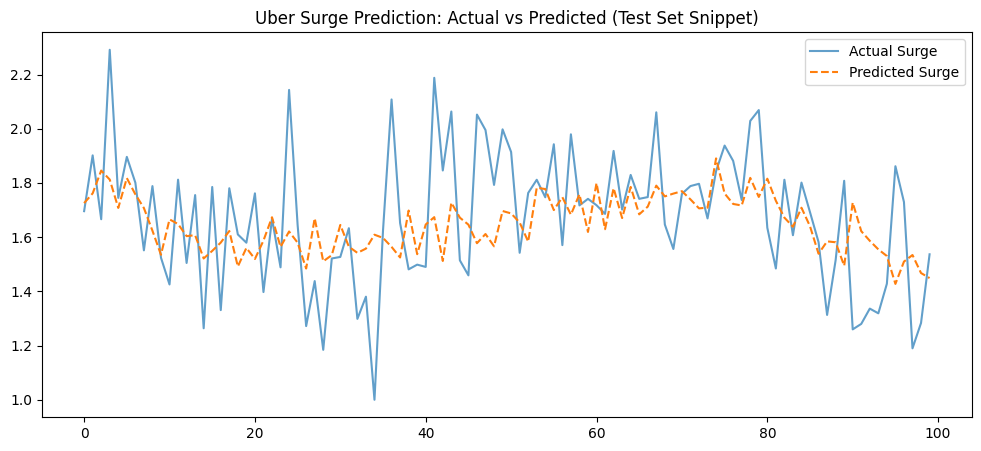

In [31]:
#We evaluate using MAE (Average error in surge points) and RMSE (which penalizes large misses heavily)
mae = mean_absolute_error(y_test, y_pred)

rmse= np.sqrt(mean_squared_error(y_test, y_pred))

r2= r2_score(y_test, y_pred)

print(f"Model Performance:")

print(f"MAE: (mae:.4f)")

print(f"RMSE: (rmse:.4f)")

print(f"R2 Score: (r2:.4f)")

#Visualizing Real vs Predicted

plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:100], label='Actual Surge', alpha=0.7)

plt.plot(y_pred[:100], label='Predicted Surge', linestyle='--')

plt.title("Uber Surge Prediction: Actual vs Predicted (Test Set Snippet)")
plt.legend()

plt.show()